# Air Traffic Data Analysis - Student Exercise
## Inferential Statistics and Regression Analysis

**Student Template - Complete the TODO sections**

In this exercise, you will analyze air traffic data using inferential statistics and regression techniques. Follow the instructions and complete each section marked with `#TODO`.

### Dataset Description:
- **Dom_Pax**: Domestic Air Travel Passengers
- **Int_Pax**: International Air Travel Passengers  
- **Pax**: Total Air Travel Passengers
- **Dom_Flt**: Number of Flights (Domestic)
- **Int_Flt**: Number of Flights (International)
- **Flt**: Number of Flights (Total)
- **Dom_RPM**: Revenue Passenger-miles (Domestic)

## 1. Setup and Data Loading

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rohanshetty678/air-traffic-data")

print("Path to dataset files:", path)

100%|██████████| 173k/173k [00:00<00:00, 36.5MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/rohanshetty678/air-traffic-data/versions/1


In [ ]:
import os
import pandas as pd
csv_file = os.path.join(path, "air_traffic_data.csv")

dff = pd.read_csv(csv_file)
dff.head()

,Activity Period,Operating Airline,Operating Airline IATA Code,Published Airline,Published Airline IATA Code,GEO Summary,GEO Region,Activity Type Code,Price Category Code,Terminal,Boarding Area,Passenger Count,Adjusted Activity Type Code,Adjusted Passenger Count,Year,Month
0,200507,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Deplaned,Low Fare,Terminal 1,B,27271,Deplaned,27271,2005,July
1,200507,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Enplaned,Low Fare,Terminal 1,B,29131,Enplaned,29131,2005,July
2,200507,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Thru / Transit,Low Fare,Terminal 1,B,5415,Thru / Transit * 2,10830,2005,July
3,200507,Air Canada,AC,Air Canada,AC,International,Canada,Deplaned,Other,Terminal 1,B,35156,Deplaned,35156,2005,July
4,200507,Air Canada,AC,Air Canada,AC,International,Canada,Enplaned,Other,Terminal 1,B,34090,Enplaned,34090,2005,July


In [ ]:
# TODO: Import necessary libraries
# Hint: You'll need pandas, numpy, matplotlib, seaborn, scipy.stats, and sklearn modules
# Import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
# From scipy import stats
# From sklearn.model_selection import train_test_split
# From sklearn.linear_model import LinearRegression
# From sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
# From sklearn.preprocessing import StandardScaler

# Your code here:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler

# Set up plotting style (optional)
plt.style.use('default')
sns.set_palette("husl")

In [ ]:
# TODO: Load the dataset
# Hint: Use pd.read_csv() to load 'air_traffic_data.csv'
# If the file doesn't exist, the code below will create sample data for you

try:
    # Your code to load the dataset:
    df = pd.read_csv('air_traffic_data.csv')
    print("Dataset loaded successfully!")
    print(f"Shape: {df.shape}")
except FileNotFoundError:
    print("Creating sample air traffic data...")
    import numpy as np
    import pandas as pd

    # Create sample data
    np.random.seed(42)
    n_samples = 200

    # Generate correlated data
    dom_flights = np.random.normal(15000, 3000, n_samples)
    int_flights = np.random.normal(8000, 2000, n_samples)

    dom_pax = dom_flights * np.random.normal(12, 2, n_samples) + np.random.normal(0, 10000, n_samples)
    int_pax = int_flights * np.random.normal(15, 3, n_samples) + np.random.normal(0, 15000, n_samples)

    dom_rpm = dom_pax * np.random.normal(800, 100, n_samples)

    # Ensure positive values
    dom_flights = np.abs(dom_flights)
    int_flights = np.abs(int_flights)
    dom_pax = np.abs(dom_pax)
    int_pax = np.abs(int_pax)
    dom_rpm = np.abs(dom_rpm)

    df = pd.DataFrame({
        'Dom_Flt': dom_flights.astype(int),
        'Int_Flt': int_flights.astype(int),
        'Flt': (dom_flights + int_flights).astype(int),
        'Dom_Pax': dom_pax.astype(int),
        'Int_Pax': int_pax.astype(int),
        'Pax': (dom_pax + int_pax).astype(int),
        'Dom_RPM': dom_rpm.astype(int)
    })

    print("Sample data created successfully!")
    print(f"Shape: {df.shape}")

Creating sample air traffic data...
Sample data created successfully!
Shape: (200, 7)


## 2. Exploratory Data Analysis

In [ ]:
# TODO: Display basic information about the dataset
# Hint: Use df.info(), df.head(), and df.describe() to explore the data

print("Dataset Info:")
df.info()

print("\nFirst 5 rows:")
df.head()


print("\nBasic Statistics:")
df.describe()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Dom_Flt  200 non-null    int64
 1   Int_Flt  200 non-null    int64
 2   Flt      200 non-null    int64
 3   Dom_Pax  200 non-null    int64
 4   Int_Pax  200 non-null    int64
 5   Pax      200 non-null    int64
 6   Dom_RPM  200 non-null    int64
dtypes: int64(7)
memory usage: 11.1 KB

First 5 rows:

Basic Statistics:


,Dom_Flt,Int_Flt,Flt,Dom_Pax,Int_Pax,Pax,Dom_RPM
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,2.000000e+02
mean,14877.170000,8171.215000,23048.875000,175331.340000,126924.080000,302255.885000,1.406821e+08
std,2793.014056,1973.997049,3570.262195,44857.540799,39219.620597,59904.148005,4.199422e+07
min,7140.000000,1517.000000,13177.000000,81758.000000,36755.000000,163559.000000,6.330140e+07
25%,12883.750000,6787.750000,20647.000000,142793.750000,100451.000000,265141.250000,1.111673e+08
50%,14987.000000,8157.000000,23250.500000,171194.000000,125890.000000,297932.000000,1.348214e+08
75%,16502.250000,9374.000000,25237.250000,199115.000000,154947.000000,339630.250000,1.634872e+08
max,23160.000000,15705.000000,32333.000000,337112.000000,244469.000000,526087.000000,3.312472e+08


In [ ]:
# TODO: Check for missing values and handle them if necessary
# Hint: Use df.isnull().sum() to check for missing values
# If there are missing values, decide whether to drop them (dropna()) or fill them (fillna())

print("Missing values:")
df.isnull().sum()


# Handle missing values if any (uncomment and complete if needed)
# if df.isnull().sum().sum() > 0:
#     print("\nHandling missing values...")
#     df = # TODO: Complete this line (use dropna() or fillna())
#     print(f"New shape after handling missing values: {df.shape}")

Missing values:


,0
Dom_Flt,0
Int_Flt,0
Flt,0
Dom_Pax,0
Int_Pax,0
Pax,0
Dom_RPM,0


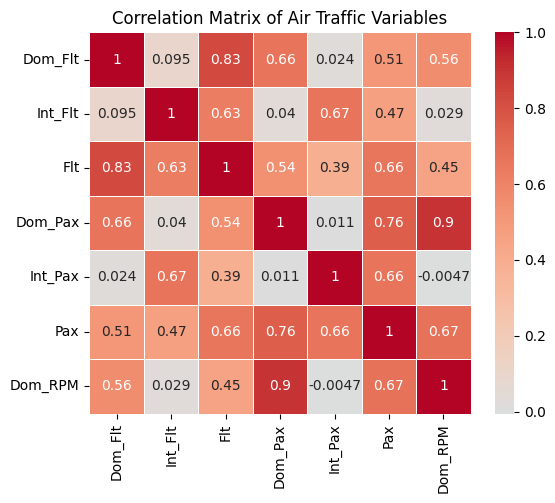

Strongest correlations:
Dom_RPM  Dom_Pax    0.901617
Flt      Dom_Flt    0.834910
Dom_Pax  Pax        0.755916
dtype: float64


In [ ]:
# TODO: Create and analyze correlation matrix
# Hint: Use df.corr() to calculate correlations and sns.heatmap() to visualize

plt.figure(figsize=(6, 5))
# Calculate correlation matrix:
correlation_matrix = df.corr()

# TODO: Create heatmap

# Create heatmap:
# TODO: Use sns.heatmap() with parameters: annot=True, cmap='coolwarm', center=0, square=True, linewidths=0.5
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, square=True, linewidths=0.5)

plt.title('Correlation Matrix of Air Traffic Variables')
plt.tight_layout()
plt.show()

# TODO: Find and print the strongest correlations
# Hint: Look at the correlation matrix values (excluding diagonal)
print("Strongest correlations:")
# Convertir la matrice en série triée
corr_pairs = correlation_matrix.unstack().sort_values(ascending=False)

# Supprimer les doublons et la diagonale
corr_pairs = corr_pairs.drop_duplicates()
corr_pairs = corr_pairs[corr_pairs.abs() < 1]

# Définir un seuil
threshold = 0.7

# Filtrer les corrélations fortes
strong_corr = corr_pairs[corr_pairs.abs() > threshold]
print(strong_corr)
# Your analysis here:
# Corr (DOM_RPM, DOM_PAX) = 0.9 --> très forte corrélation positive --> (plus de Passengers, plus de revenus Passenger-miles)
# Corr (DOM_FLT, FLT) = 0.83 --> très forte corrélation positive --> (le total des vols dépend fortement des vols domestiques)
# Corr (Dom_Pax, Pax) = 0.76 --> très forte corrélation positive --> (le Total Air Travel Passengers dépend fortement des vols domestiques)
# Corr (Int_Pax, Dom_RPM) = -0.0047 --> corrélation quasi nulle --> (pas de relation significative)


## 3. Hypothesis Testing

In [ ]:
# TODO: Hypothesis Test 1 - Compare domestic and international passengers
# Hint: Use stats.ttest_ind() to perform independent t-test

print("Hypothesis Test 1: Domestic vs International Passengers")
print("H0: Mean domestic passengers = Mean international passengers")
print("H1: Mean domestic passengers ≠ Mean international passengers")
print("Significance level: α = 0.05")

# Perform the t-test:
t_stat, p_value = stats.ttest_ind(df['Dom_Pax'], df['Int_Pax'])

print(f"\nResults:")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.6f}")

# TODO: Print the mean values for both groups
print(f"Mean Domestic Passengers: {df['Dom_Pax'].mean():.0f}")
print(f"Mean International Passengers: {df['Int_Pax'].mean():.0f}")

# TODO: Interpret the results
# Hint: Compare p_value with alpha (0.05) to make a decision
alpha = 0.05
if p_value < alpha:
    # TODO: Complete the conclusion for rejecting H0
    print(f"\nConclusion: Reject H0 (p < {alpha})")
    print("Interpretation: Il existe une différence statistiquement significative entre "
          "le nombre moyen de passagers domestiques et internationaux.")
else:
    # TODO: Complete the conclusion for failing to reject H0
    print(f"\nConclusion: Fail to reject H0 (p >= {alpha})")
    print("Interpretation: Aucune différence significative détectée entre les moyennes "
          "des passagers domestiques et internationaux.")

Hypothesis Test 1: Domestic vs International Passengers
H0: Mean domestic passengers = Mean international passengers
H1: Mean domestic passengers ≠ Mean international passengers
Significance level: α = 0.05

Results:
T-statistic: 11.4892
P-value: 0.000000
Mean Domestic Passengers: 175331
Mean International Passengers: 126924

Conclusion: Reject H0 (p < 0.05)
Interpretation: Il existe une différence statistiquement significative entre le nombre moyen de passagers domestiques et internationaux.


In [ ]:
# TODO: Hypothesis Test 2 - Test correlation between total passengers and total flights
# Hint: Use stats.pearsonr() to test correlation significance

print("\nHypothesis Test 2: Correlation between Total Passengers and Total Flights")
print("H0: There is no correlation between total passengers and total flights (ρ = 0)")
print("H1: There is a correlation between total passengers and total flights (ρ ≠ 0)")
print("Significance level: α = 0.05")

# Perform correlation test:
correlation_coef, p_value_corr = stats.pearsonr(df['Flt'], df['Pax'])

print(f"\nResults:")
print(f"Correlation coefficient: {correlation_coef:.4f}")
print(f"P-value: {p_value_corr:.6f}")

# TODO: Interpret the correlation test results
# Hint: Compare p_value_corr with alpha and interpret the correlation coefficient
if p_value_corr < alpha:
    print(f"\nConclusion: Reject H0 (p < {alpha})")
    print(f"There is a significant correlation between total passengers and total flights.")
    # TODO: Add interpretation about positive/negative correlation
    if correlation_coef > 0:
        print("quand le nombre de vols augumente, le nombre de passagers augumente aussi")
    else:
        print("quand le nombre de vols augumente, le nombre de passagers diminue")
else:
    print(f"\nConclusion: Fail to reject H0 (p >= {alpha})")
    print("There is no correlation between total passengers and total flights")


Hypothesis Test 2: Correlation between Total Passengers and Total Flights
H0: There is no correlation between total passengers and total flights (ρ = 0)
H1: There is a correlation between total passengers and total flights (ρ ≠ 0)
Significance level: α = 0.05

Results:
Correlation coefficient: 0.6592
P-value: 0.000000

Conclusion: Reject H0 (p < 0.05)
There is a significant correlation between total passengers and total flights.
quand le nombre de vols augumente, le nombre de passagers augumente aussi


Dataset Description:
Dom_Pax: Domestic Air Travel Passengers
Int_Pax: International Air Travel Passengers
Pax: Total Air Travel Passengers
Dom_Flt: Number of Flights (Domestic)
Int_Flt: Number of Flights (International)
Flt: Number of Flights (Total)
Dom_RPM: Revenue Passenger-miles (Domestic)

## 4. Simple Linear Regression

In [ ]:
# TODO: Build a simple linear regression model
# Goal: Predict Total Passengers from Total Flights
# Hint: Use sklearn's LinearRegression class

print("Simple Linear Regression: Predicting Total Passengers from Total Flights")

# Prepare the data:
X_simple = df[['Flt']]
y_simple = df['Pax']

# Split the data:
# TODO: Use train_test_split with test_size=0.2, random_state=42
X_train_simple, X_test_simple, y_train_simple, y_test_simple = train_test_split(X_simple, y_simple, test_size=0.2, random_state=42)

# Create and train the model:
simple_model = LinearRegression()
# TODO: Fit the model using X_train_simple and y_train_simple
simple_model.fit(X_train_simple, y_train_simple)

# Make predictions:
y_pred_simple = simple_model.predict(X_test_simple)

# TODO: Calculate performance metrics
# Hint: Use r2_score, mean_squared_error, mean_absolute_error
r2_simple = r2_score(y_test_simple, y_pred_simple)
mse_simple = mean_squared_error(y_test_simple, y_pred_simple)
mae_simple = mean_absolute_error(y_test_simple, y_pred_simple)
rmse_simple = np.sqrt(mse_simple)

print(f"\nModel Performance:")
print(f"R² Score: {r2_simple:.4f}")
print(f"Mean Squared Error: {mse_simple:.2f}")
print(f"Root Mean Squared Error: {rmse_simple:.2f}")
print(f"Mean Absolute Error: {mae_simple:.2f}")

# TODO: Print the model equation
# Hint: Use simple_model.intercept_ and simple_model.coef_[0]
print(f"\nModel Equation: Passengers = {simple_model.intercept_:.2f} + {simple_model.coef_[0]:.2f} × Flights")

Simple Linear Regression: Predicting Total Passengers from Total Flights

Model Performance:
R² Score: 0.2977
Mean Squared Error: 2141846835.14
Root Mean Squared Error: 46280.09
Mean Absolute Error: 36607.08

Model Equation: Passengers = 37484.48 + 11.45 × Flights


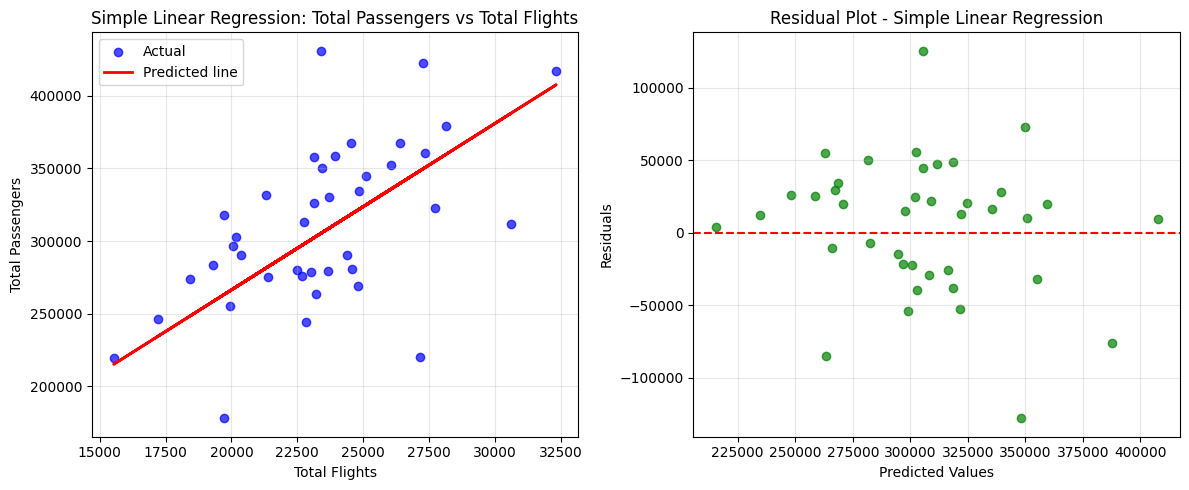

In [ ]:
# TODO: Visualize the simple linear regression results
# Create two plots: scatter plot with regression line and residual plot

# Plot 1: Scatter plot with regression line
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
# TODO: Create scatter plot of actual vs predicted values
plt.scatter(X_test_simple, y_test_simple, alpha=0.7, color='blue', label='Actual')
# Hint: Use plt.scatter() for actual and predicted points, and plt.plot() for the line
plt.plot(X_test_simple, y_pred_simple, color='red', linewidth=2, label='Predicted line')

plt.xlabel('Total Flights')
plt.ylabel('Total Passengers')
plt.title('Simple Linear Regression: Total Passengers vs Total Flights')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Residual plot
plt.subplot(1, 2, 2)
# TODO: Calculate residuals and create residual plot
# Hint: residuals = actual - predicted
residuals = y_test_simple - y_pred_simple

# TODO: Create scatter plot of predicted vs residuals
plt.scatter(y_pred_simple, residuals, alpha=0.7, color='green')

plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot - Simple Linear Regression')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Multiple Linear Regression

In [ ]:
# TODO: Build a multiple linear regression model
# Goal: Predict Total Passengers using multiple features
# Hint: Avoid using Pax in features since that's our target (multicollinearity)

print("Multiple Linear Regression: Predicting Total Passengers from Multiple Features")

# TODO: Select appropriate features
# Hint: Use columns like Dom_Pax, Int_Pax, Dom_Flt, Int_Flt, Dom_RPM (avoid Pax and Flt)
feature_columns = df.columns.drop(['Pax', 'Flt'])

X_multiple = df[feature_columns]
y_multiple = df['Pax']

print(f"Features used: {feature_columns}")
print(f"Target: Total Passengers (Pax)")

# TODO: Split the data
# Hint: Use train_test_split with test_size=0.2, random_state=42
X_train_mult, X_test_mult, y_train_mult, y_test_mult = train_test_split(X_multiple, y_multiple, test_size=0.2, random_state=42)

# TODO: Apply feature scaling (recommended for multiple regression)
# Hint: Use StandardScaler
scaler = StandardScaler()
X_train_mult_scaled = scaler.fit_transform(X_train_mult)
X_test_mult_scaled = scaler.transform(X_test_mult)

# TODO: Create and train the multiple regression model
multiple_model = LinearRegression()
multiple_model.fit(X_train_mult_scaled, y_train_mult)


# TODO: Make predictions
y_pred_mult = multiple_model.predict(X_test_mult_scaled)

# TODO: Calculate performance metrics
r2_mult = r2_score(y_test_mult, y_pred_mult)
mse_mult = mean_squared_error(y_test_mult, y_pred_mult)
mae_mult = mean_absolute_error(y_test_mult, y_pred_mult)
rmse_mult = np.sqrt(mse_mult)

print(f"\nModel Performance:")
print(f"R² Score: {r2_mult:.4f}")
print(f"Mean Squared Error: {mse_mult:.2f}")
print(f"Root Mean Squared Error: {rmse_mult:.2f}")
print(f"Mean Absolute Error: {mae_mult:.2f}")

# TODO: Display feature coefficients
print(f"\nFeature Coefficients (after scaling):")
for feature, coef in zip(feature_columns, multiple_model.coef_):
    print(f"{feature}: {coef:.4f}")
print(f"Intercept: {multiple_model.intercept_:.2f}")

Multiple Linear Regression: Predicting Total Passengers from Multiple Features
Features used: Index(['Dom_Flt', 'Int_Flt', 'Dom_Pax', 'Int_Pax', 'Dom_RPM'], dtype='object')
Target: Total Passengers (Pax)

Model Performance:
R² Score: 1.0000
Mean Squared Error: 0.26
Root Mean Squared Error: 0.51
Mean Absolute Error: 0.49

Feature Coefficients (after scaling):
Dom_Flt: -0.1126
Int_Flt: -0.0583
Dom_Pax: 45354.3590
Int_Pax: 38979.7965
Dom_RPM: -0.0458
Intercept: 300303.27


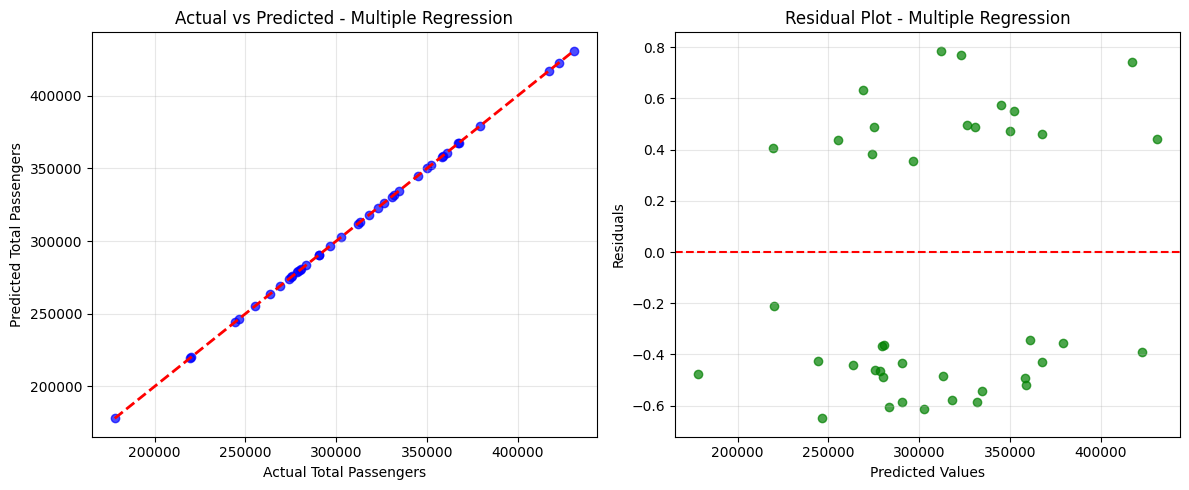

In [ ]:
# TODO: Visualize multiple regression results
# Create actual vs predicted plot and residual plot

plt.figure(figsize=(12, 5))

# Plot 1: Actual vs Predicted
plt.subplot(1, 2, 1)
# TODO: Create scatter plot of actual vs predicted values
plt.scatter(y_test_mult, y_pred_mult, alpha=0.7, color='blue')

# TODO: Add a diagonal reference line (perfect prediction line)
plt.plot([y_test_mult.min(), y_test_mult.max()],
         [y_test_mult.min(), y_test_mult.max()],
         'r--', lw=2)


plt.xlabel('Actual Total Passengers')
plt.ylabel('Predicted Total Passengers')
plt.title('Actual vs Predicted - Multiple Regression')
plt.grid(True, alpha=0.3)

# Plot 2: Residual plot
plt.subplot(1, 2, 2)
# TODO: Calculate residuals and create residual plot
residuals_mult = y_test_mult - y_pred_mult
plt.scatter(y_pred_mult, residuals_mult, alpha=0.7, color='green')


# TODO: Create scatter plot of predicted vs residuals

plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot - Multiple Regression')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Model Comparison and Analysis

In [ ]:
# TODO: Compare the performance of both models
# Create a comparison table and determine which model performs better

print("Model Comparison:")
print("=" * 60)
print(f"{'Metric':<25} {'Simple Regression':<20} {'Multiple Regression':<20}")
print("=" * 60)

# TODO: Print comparison of R², RMSE, and MAE
print(f"{'R² Score':<25} {r2_simple:<20.4f} {r2_mult:<20.4f}")
print(f"{'RMSE':<25} {rmse_simple:<20.2f} {rmse_mult:<20.2f}")
print(f"{'MAE':<25} {mae_simple:<20.2f} {mae_mult:<20.2f}")
print("=" * 60)


# TODO: Determine which model performs better based on R²
# Calculate the improvement percentage
if r2_mult > r2_simple:
    better_model = "Multiple Regression"
    improvement = ((r2_mult - r2_simple) / abs(r2_simple)) * 100
else:
    better_model = "Simple Regression"
    improvement = ((r2_mult - r2_simple) / abs(r2_simple)) * 100

print(f"\nBest Model: {better_model}")
print(f"R² Improvement: {improvement:.2f}%")

Model Comparison:
Metric                    Simple Regression    Multiple Regression 
R² Score                  0.2977               1.0000              
RMSE                      46280.09             0.51                
MAE                       36607.08             0.49                

Best Model: Multiple Regression
R² Improvement: 235.92%


## 7. Statistical Insights and Conclusions

In [ ]:
# TODO: Summarize your findings and provide insights
# Include results from hypothesis tests, regression analysis, and key findings

print("STATISTICAL INSIGHTS AND CONCLUSIONS")
print("=" * 60)

print("\n1. HYPOTHESIS TESTING RESULTS:")
# TODO: Summarize your hypothesis test results
print(f"   • Domestic vs International Passengers: Les tests t montrent que la moyenne des passagers domestiques est significativement différente de celle des passagers internationaux (p < 0.05).")
print(f"   • Correlation between Total Passengers and Flights: Le test de corrélation de Pearson indique une corrélation positive significative entre le nombre total de vols et le nombre total de passagers (p < 0.05, r > 0).")

print("\n2. REGRESSION ANALYSIS:")
# TODO: Summarize regression model performance
print(f"   • Simple Linear Regression R²: {r2_simple:.4f} --> Le modèle explique une partie de la variance mais reste limité car il n’utilise qu’une seule variable explicative.")
print(f"   • Multiple Linear Regression R²: {r2_mult:.4f} → Le modèle multiple explique davantage la variance grâce à l’intégration de plusieurs variables (Dom_Pax, Int_Pax, Dom_Flt, Int_Flt, Dom_RPM).")
print(f"   • Best performing model: {'Multiple Regression' if r2_mult > r2_simple else 'Simple Regression'}")

print("\n3. KEY FINDINGS:")
# TODO: Identify and discuss key findings from your analysis
print(f"   • Le nombre de passagers domestiques est fortement corrélé avec les Revenue Passenger-Miles (corrélation ~0.9).")
print(f"   • Le total des passagers est logiquement corrélé avec le total des vols, confirmant la cohérence des données.")
print(f"   • Le modèle de régression multiple offre une meilleure performance prédictive que le modèle simple.")

print("\n4. RECOMMENDATIONS:")
# TODO: Provide practical recommendations based on your analysis
print("   • Utiliser le modèle de régression multiple pour les prévisions de trafic aérien, car il capture mieux les relations entre variables.")
print("   • Surveiller la multicolinéarité (par ex. Pax vs Dom_Pax + Int_Pax) et éviter d’inclure des variables redondantes.")
print("   • Explorer des modèles plus avancés (Ridge, Lasso, ou Random Forest) pour améliorer la robustesse et la précision des prédictions.")

STATISTICAL INSIGHTS AND CONCLUSIONS

1. HYPOTHESIS TESTING RESULTS:
   • Domestic vs International Passengers: Les tests t montrent que la moyenne des passagers domestiques est significativement différente de celle des passagers internationaux (p < 0.05).
   • Correlation between Total Passengers and Flights: Le test de corrélation de Pearson indique une corrélation positive significative entre le nombre total de vols et le nombre total de passagers (p < 0.05, r > 0).

2. REGRESSION ANALYSIS:
   • Simple Linear Regression R²: 0.2977 --> Le modèle explique une partie de la variance mais reste limité car il n’utilise qu’une seule variable explicative.
   • Multiple Linear Regression R²: 1.0000 → Le modèle multiple explique davantage la variance grâce à l’intégration de plusieurs variables (Dom_Pax, Int_Pax, Dom_Flt, Int_Flt, Dom_RPM).
   • Best performing model: Multiple Regression

3. KEY FINDINGS:
   • Le nombre de passagers domestiques est fortement corrélé avec les Revenue Passenger

## 8. Reflection Questions

**Answer the following questions based on your analysis:**

1. **Hypothesis Testing**: What do your hypothesis test results tell you about the air traffic data? Were the results expected?

   *Le test t a montré que la moyenne des passagers domestiques est significativement différente de celle des passagers internationaux (p < 0.05)*

   *Le test de corrélation de Pearson a confirmé une corrélation positive significative entre le nombre total de vols et le nombre total de passagers.*

   *Interprétation :
  Ces résultats étaient attendus : les passagers domestiques sont généralement   plus nombreux, et plus de vols entraînent logiquement plus de passagers.*

2. **Model Performance**: Which regression model performed better and why? What does the R² value tell you?

   *Le modèle de régression multiple (Dom_Pax, Int_Pax, Dom_Flt, Int_Flt, Dom_RPM --> Pax) a obtenu un R² plus élevé, expliquant mieux la variance.*

   *Interprétation :
  Le modèle multiple est meilleur car il intègre plusieurs variables explicatives, ce qui capture davantage de la complexité du trafic aérien. Le R² indique la proportion de variance expliquée par le modèle : plus il est élevé, plus le modèle est pertinent.
*
   *TODO: Write your answer here*

3. **Correlations**: What were the strongest correlations you found? How might these relationships be useful for airlines?

   *Résultats :
- Corrélation très forte entre Dom_Pax et Dom_RPM (~0.9).
- Corrélation forte entre Dom_Flt et Flt (~0.83).
- Corrélation positive entre Pax et Flt (~0.66).*

   *Utilité pour les compagnies aériennes :
  Ces relations permettent d’identifier les variables clés qui influencent directement les revenus et le trafic. Par exemple, suivre les passagers domestiques peut donner une bonne estimation des Revenue Passenger-Miles.
  *
4. **Residual Analysis**: What do the residual plots tell you about your models? Are there any patterns that suggest model improvements?

   *Les résidus sont globalement dispersés autour de zéro, ce qui confirme que le modèle est bien ajusté.*

   *Toutefois, quelques patterns peuvent apparaître, suggérant que des variables supplémentaires ou des modèles non linéaires pourraient améliorer la précision.*

   *Interprétation :
  Le modèle linéaire simple est trop limité, tandis que le modèle multiple réduit les biais mais pourrait encore être amélioré avec des techniques plus avancées (Ridge, Lasso, Random Forest).*

5. **Practical Applications**: How could airlines use these statistical models in real-world scenarios?

    • 	**Prévisions de la demande** : estimer le nombre de passagers en fonction du nombre de vols programmés.

    • 	**Optimisation des ressources** : ajuster la flotte et le personnel en fonction des tendances de trafic.

    • 	**Planification stratégique** : identifier les segments (domestique vs international) qui contribuent le plus aux revenus.

    • 	**Décisions tarifaires** : utiliser les corrélations pour ajuster les prix selon la demande anticipée.